In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_parquet('../data/cleaned/combined_cleaned.parquet')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{sorted(df.columns.tolist())}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (2409, 26)

Columns:
['age', 'amenities', 'area', 'balcony', 'bathroom', 'bhk', 'city', 'city_tier', 'facing', 'floor', 'floor_pos', 'furnish', 'is_near_coaching', 'is_ready', 'locality', 'log_price', 'nearbylocations', 'parking', 'possession_year', 'price', 'property_id', 'property_type', 'scraped_at', 'sector', 'source', 'total_floors']

Dtypes:
property_id          object
city                 object
property_type        object
price               float64
area                float64
bhk                   int32
bathroom              int32
balcony               int32
floor_pos             int32
total_floors          int32
furnish              object
locality             object
sector               object
parking               int32
possession_year       int64
is_ready              int64
is_near_coaching      int32
source               object
scraped_at           object
age                  object
amenities            object
floor               float64
nearbylocations     float64

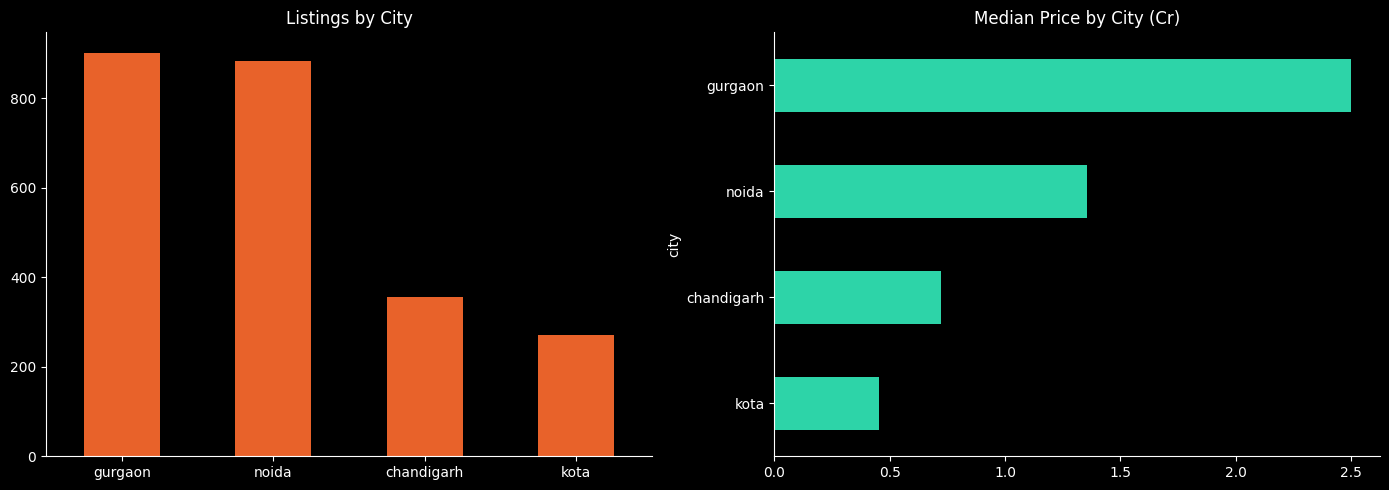

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['city'].value_counts().plot(kind='bar', ax=axes[0], color='#E8622A', edgecolor='none')
axes[0].set_title('Listings by City')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('city')['price'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='#2DD4A8', edgecolor='none'
)
axes[1].set_title('Median Price by City (Cr)')
plt.tight_layout()
plt.savefig('../reports/eda_city_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

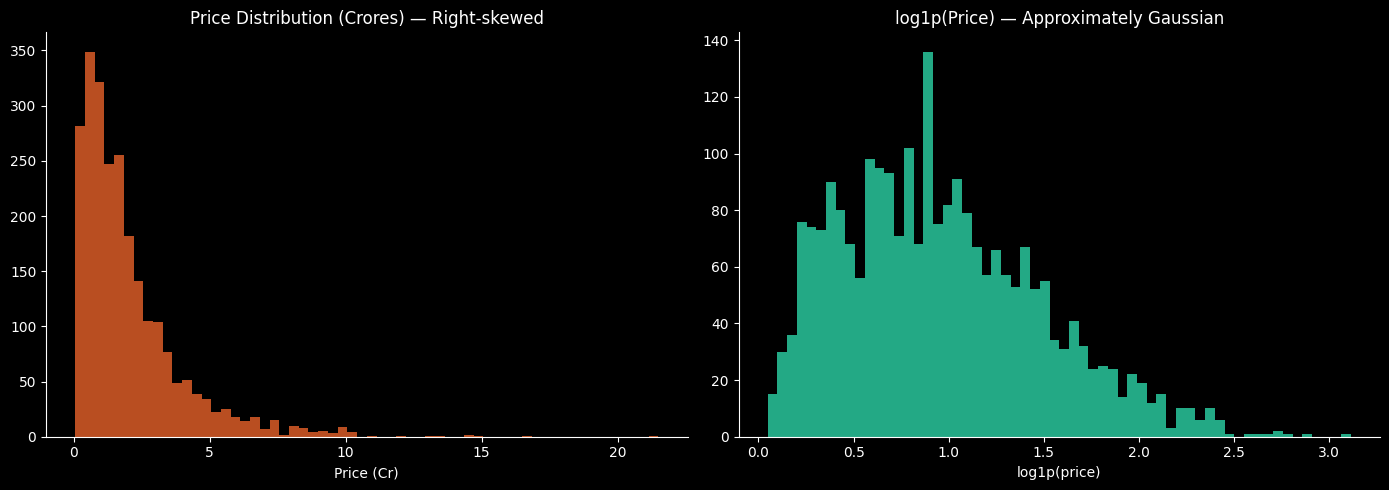

Skewness — raw price: 2.51
Skewness — log_price: 0.6


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, color='#E8622A', edgecolor='none', alpha=0.8)
axes[0].set_title('Price Distribution (Crores) — Right-skewed')
axes[0].set_xlabel('Price (Cr)')

axes[1].hist(df['log_price'], bins=60, color='#2DD4A8', edgecolor='none', alpha=0.8)
axes[1].set_title('log1p(Price) — Approximately Gaussian')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.savefig('../reports/eda_price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("Skewness — raw price:", round(df['price'].skew(), 2))
print("Skewness — log_price:", round(df['log_price'].skew(), 2))

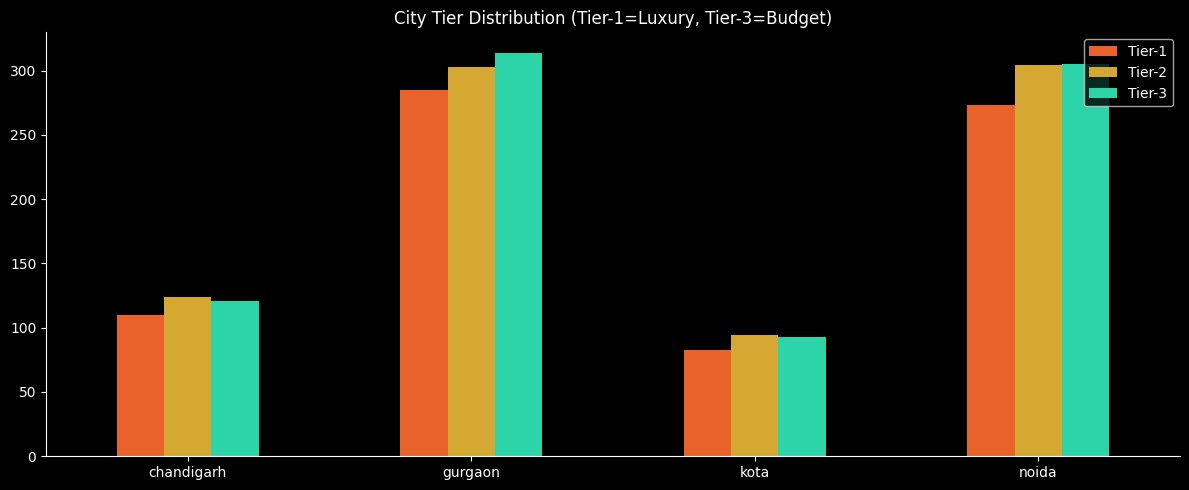

In [4]:
tier_counts = df.groupby(['city', 'city_tier']).size().unstack(fill_value=0)
tier_counts.plot(kind='bar', figsize=(12, 5), color=['#E8622A', '#D4A832', '#2DD4A8'])
plt.title('City Tier Distribution (Tier-1=Luxury, Tier-3=Budget)')
plt.xlabel('')
plt.tick_params(axis='x', rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reports/eda_city_tiers.png', dpi=120, bbox_inches='tight')
plt.show()

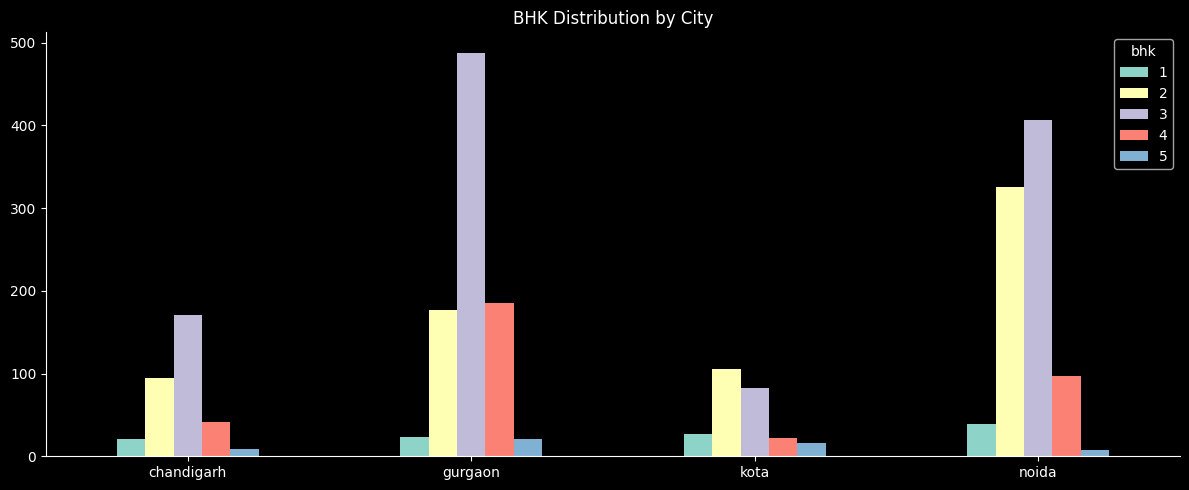

In [5]:
bhk_dist = df.groupby(['city', 'bhk']).size().unstack(fill_value=0)
bhk_dist[[1, 2, 3, 4, 5]].plot(kind='bar', figsize=(12, 5))
plt.title('BHK Distribution by City')
plt.xlabel('')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../reports/eda_bhk_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

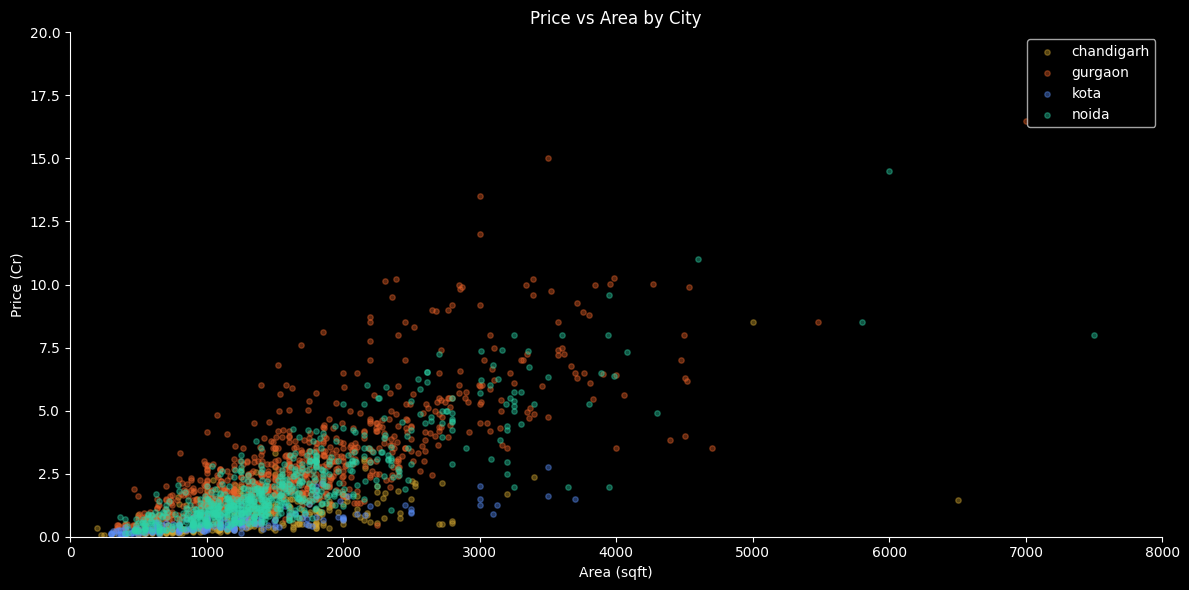

In [6]:
sample = df.sample(min(2000, len(df)), random_state=42)
colors = {'gurgaon': '#E8622A', 'noida': '#2DD4A8', 'chandigarh': '#D4A832', 'kota': '#5B8FF9'}

fig, ax = plt.subplots(figsize=(12, 6))
for city, group in sample.groupby('city'):
    ax.scatter(group['area'], group['price'], alpha=0.4, s=15,
               color=colors.get(city, 'white'), label=city)

ax.set_xlabel('Area (sqft)')
ax.set_ylabel('Price (Cr)')
ax.set_title('Price vs Area by City')
ax.legend()
ax.set_xlim(0, 8000)
ax.set_ylim(0, 20)
plt.tight_layout()
plt.savefig('../reports/eda_price_vs_area.png', dpi=120, bbox_inches='tight')
plt.show()

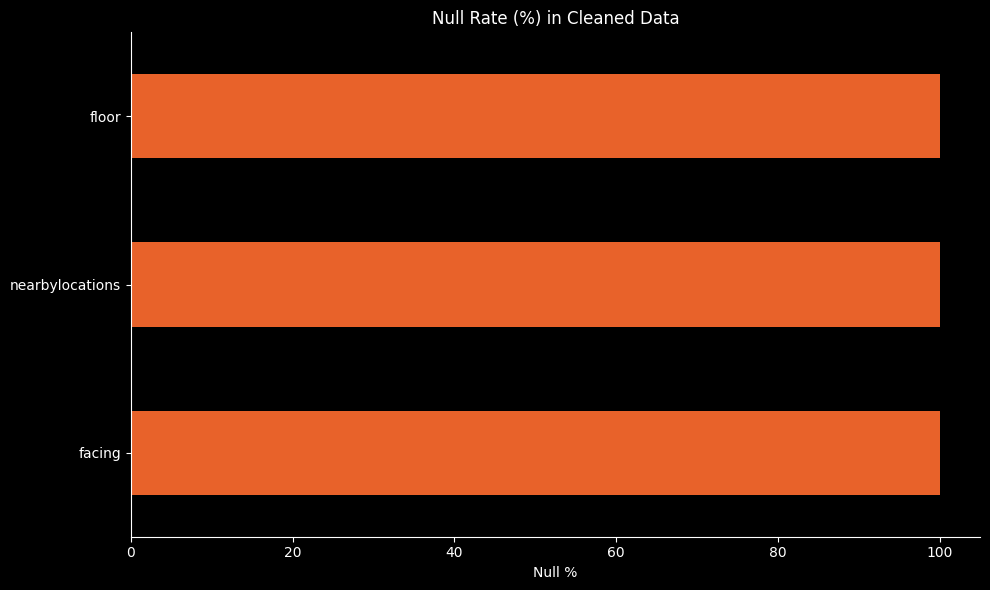

In [7]:
null_rates = (df.isna().mean() * 100).sort_values(ascending=False)
null_rates = null_rates[null_rates > 0]

if len(null_rates) > 0:
    null_rates.plot(kind='barh', color='#E8622A', figsize=(10, 6))
    plt.title('Null Rate (%) in Cleaned Data')
    plt.xlabel('Null %')
    plt.tight_layout()
    plt.savefig('../reports/eda_null_rates.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No null values in cleaned data ✅")

In [8]:
print("=" * 50)
print("CLEANING PIPELINE SUMMARY")
print("=" * 50)
print(f"Total rows:          {len(df):,}")
print(f"Cities:              {df['city'].nunique()}")
print(f"Property types:      {df['property_type'].value_counts().to_dict()}")
print(f"Price range:         ₹{df['price'].min():.2f}Cr – ₹{df['price'].max():.2f}Cr")
print(f"Price median:        ₹{df['price'].median():.2f}Cr")
print(f"Area range:          {df['area'].min():.0f} – {df['area'].max():.0f} sqft")
print(f"log_price range:     {df['log_price'].min():.3f} – {df['log_price'].max():.3f}")
print(f"log_price skewness:  {df['log_price'].skew():.3f}")
print(f"Null cells:          {df.isna().sum().sum()}")

CLEANING PIPELINE SUMMARY
Total rows:          2,409
Cities:              4
Property types:      {'flat': 2358, 'house': 51}
Price range:         ₹0.05Cr – ₹21.50Cr
Price median:        ₹1.49Cr
Area range:          200 – 16000 sqft
log_price range:     0.049 – 3.114
log_price skewness:  0.604
Null cells:          7227
